# Overview:

### This data analysis notebook is going to look at the regression of median earnings in 2022 to determine whether a school's athletic division status — DI, DII, or NAIA — is a meaningful predictor of its graduates' post-graduation financial outcomes. 

### Using data from the College Scorecard merged with athletic scholarship and divisional classification data, we will model median earnings as the outcome variable and examine how division status, average athletic scholarship amount, and racial demographic composition of the student-athlete body relate to where graduates end up economically.

### We will also look at the racial diversity of each divsion in the NCAA. This will acheived by taking a raw count of each race in each conference, where it will then be compared against the divison level those raw counts are in. 

# Difference between NCAA Divisions: 

### **Division I** schools have the highest athletic endowments out of all the NCAA Divisions. They have the ability to provide the highest atheltic scholarships. This generally attracts athletes that are predominently focused on their given sport. These D1 atheltes also have greater pressure to train for more time, and give high attention to their sport. 

### **Division II** schools provide athletic scholarships as well, although not nearly as high as DI schools. This means the atheltic endowment of these schools is smaller. These schools financial governing body picks to spend their general enodowmnet on areas besides sports. The student-athlete enviroment for these schools still expect focus on atheltics, although not as high demands as a D1 school. This tends to attract athletes who are inclined to spend their time on areas besides their sports, such as academics. 

### **NAIA** schools operate outside of the NCAA entirely, functioning under the National Association of Intercollegiate Athletics. While DII schools are still part of the NCAA structure and are held to its academic and eligibility standards, NAIA institutions follow a separate and generally more flexible regulatory framework. This distinction matters because NAIA schools have more autonomy over how they structure their athletic programs and distribute scholarship money. Like DII, NAIA schools are permitted to offer athletic scholarships, though these tend to be smaller and more inconsistent than DI and DII awards.

#### *Division III schools are not included given they do not provide athletic scholarship of any kind. Although, they will be included in the racial diverstiy model*

In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [15]:
athletic_df = pd.read_excel('../data/athletic_scholarship_table.xlsx')
dat = pd.read_csv('../data/Glynn_data/combined_data.csv')

## Variable Descriptions

### These data sets provide data on every school that provides athletic scholarship to their student-athletes. Specifically it provides the average athletic scholarship for both women and men atheltes at these schools, along with the division each school competes in. In addition, the other data set from the DOE priovides median earnings.
 - division: This variable provides the division each school competes in (DI,DII,NAIA)in 2022.
 - md_earn_wne_4yr: Median earnings are calculated for individuals that were federally aided, were working, and were not enrolled in school as of the measurement point. Earnings were measured based on wages and deferred compensation reported via IRS form W-2 plus positive self-employment earnings reported via Schedule SE. Individuals with $1 or more of earnings were considered to be working and were included in the median earnings calculation. 


## Part I: Cleaning up the data & merging columns

In [16]:
#Cleaning up the data columns when merging together Median earnings and school division

merged_df = athletic_df[['NCAA_school', 'division']].merge(
    dat[['univ_name', 'md_earn_wne_4yr']],
    left_on='NCAA_school',
    right_on='univ_name'
)

In [17]:
merged_df = merged_df.drop(columns=['univ_name'])

In [18]:
print(len(merged_df))
print(merged_df.head())

579
                       NCAA_school  division md_earn_wne_4yr
0   University of Alaska Fairbanks  NCAA II            67252
1   University of Alaska Anchorage  NCAA II            68777
2  Auburn University at Montgomery  NCAA II            55551
3         Alabama State University   NCAA  I           45998
4              Tuskegee University  NCAA II            69077


In [19]:
print(merged_df['division'].value_counts())

division
NCAA II     188
NCAA  I     164
NAIA        164
NCAA  I      53
NCAA II       4
NCAA I        3
Name: count, dtype: int64


In [20]:
#Used Claude here to help clean up the spacings in the column names

merged_df['division'] = merged_df['division'].astype(str)

merged_df.loc[merged_df['division'].str.contains('NCAA') & merged_df['division'].str.contains('II'), 'division'] = 'NCAA II'
merged_df.loc[
    merged_df['division'].str.contains('NCAA') &
    merged_df['division'].str.contains('I') &
    ~merged_df['division'].str.contains('II'),
    'division'
] = 'NCAA I'
merged_df.loc[merged_df['division'].str.contains('NAIA'), 'division'] = 'NAIA'
merged_df.loc[merged_df['division'] == 'DI', 'division'] = 'NCAA I'
merged_df.loc[merged_df['division'] == 'DII', 'division'] = 'NCAA II'

In [21]:
print(merged_df['division'].value_counts())

division
NCAA I     220
NCAA II    192
NAIA       164
Name: count, dtype: int64


## Part II: Looking for Statistical Significance 

### Before a regressional model is constructed, I wanted to check that there was a statistical significance between the variables I'm using. This will create more confidence when looking at the regression model.

In [22]:
merged_df['md_earn_wne_4yr'] = pd.to_numeric(merged_df['md_earn_wne_4yr'], errors='coerce')
merged_df = merged_df.dropna(subset=['md_earn_wne_4yr'])

print(merged_df['md_earn_wne_4yr'].dtype)

summary_table = merged_df.groupby('division')['md_earn_wne_4yr'].agg(['count', 'mean', 'median', 'std'])
print(summary_table)

float64
          count          mean   median           std
division                                            
NAIA        159  55222.427673  54129.0   9860.278888
NCAA I      220  70693.381818  66870.0  16702.216266
NCAA II     187  58733.828877  57090.0  10586.552403


In [23]:
#Needed some help from claude to construct how to run stat analysis

from scipy.stats import f_oneway

d1 = merged_df.loc[merged_df['division'] == 'NCAA I', 'md_earn_wne_4yr']
d2 = merged_df.loc[merged_df['division'] == 'NCAA II', 'md_earn_wne_4yr']
naia = merged_df.loc[merged_df['division'] == 'NAIA', 'md_earn_wne_4yr']

f_stat, p_val = f_oneway(d1, d2, naia)

print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 74.7470110273472
p-value: 1.6225509522310285e-29


## Part III: Relationship Model (Division status on Median earnings)

### Using median earnings (md_earn_wne_4yr) in 2022 as the reference outcome, this will compare how DI, DII, and NAIA division status each relate to graduate earnings outcomes.

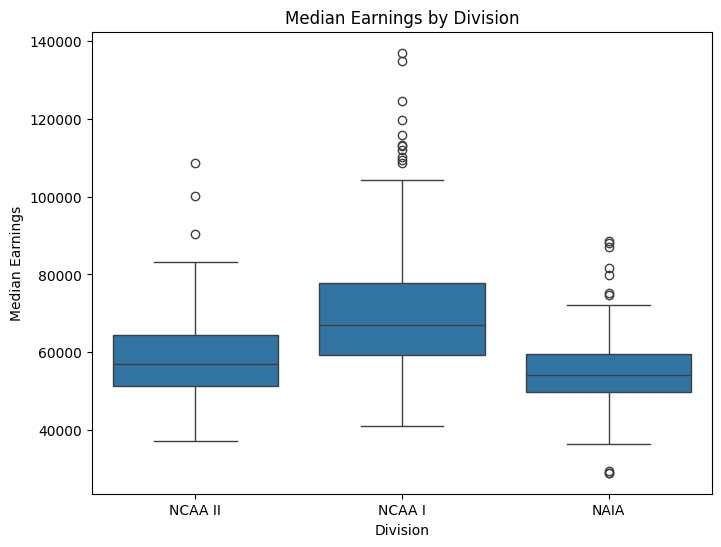

In [24]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=merged_df,
    x='division',
    y='md_earn_wne_4yr'
)

plt.title("Median Earnings by Division")
plt.xlabel("Division")
plt.ylabel("Median Earnings")

plt.show()

## Analysis 

Looking at this chart, the results actually go against what we hypothesized. DI schools come out on top with the highest median earnings, hovering around $65,000–$77,000, while DII and NAIA schools both sit lower, closer to the $55,000–$65,000 range. It seems like the prestige and institutional resources that come with being a DI school end up mattering more for graduates' earnings than we anticipated.
DII and NAIA look pretty similar to each other overall, though DII has a slightly higher median and more spread across its schools. NAIA is the most tightly clustered of the three but also has the lowest outlier in the entire dataset, meaning at least a few NAIA schools have graduates earning well below the rest of the group.

## Part IV: Racial Diversity Model (Racail Demographic on Division Level)

### Using all the race varaibles in the "NCAA conference Diversity" (2022) this will be comapred with the Division I,II, and III columns. This will show a regressional model of what racial diversity looks like in the NCAA Divison levels.

In [30]:
diversity_df = pd.read_excel('../data/division.I.II.III.diversity.xlsx')

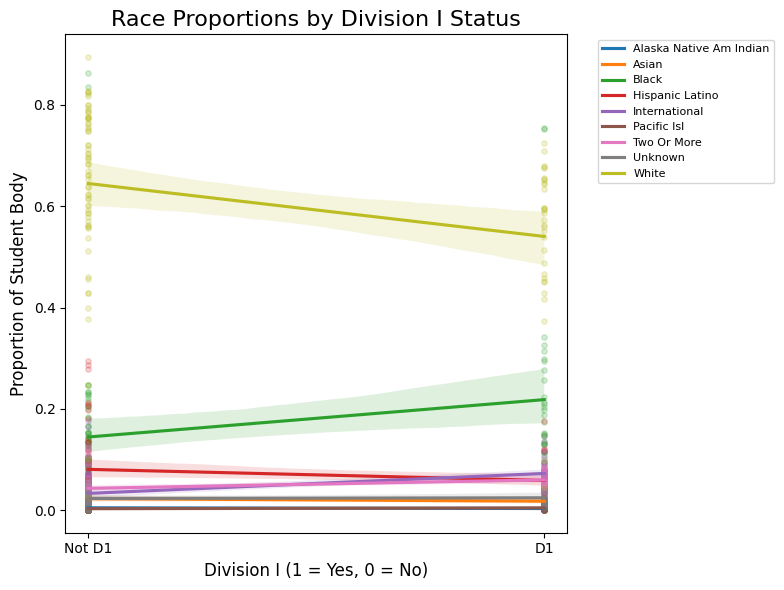

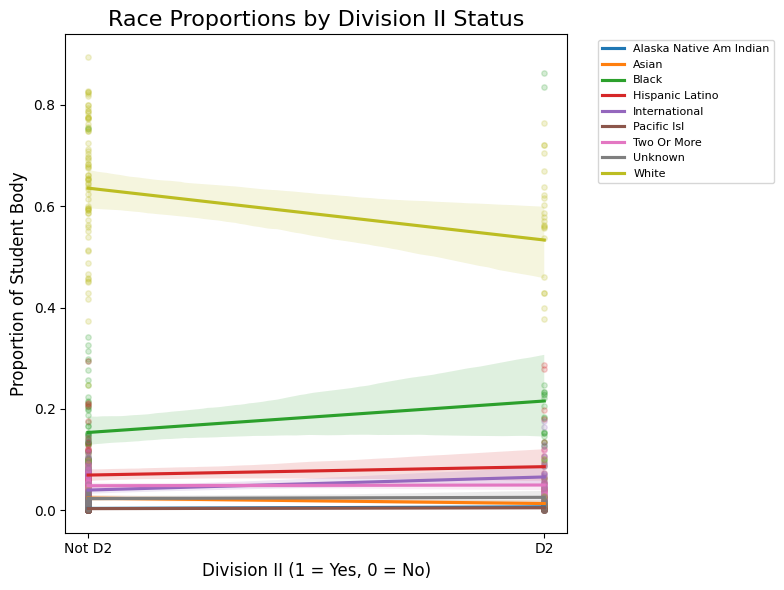

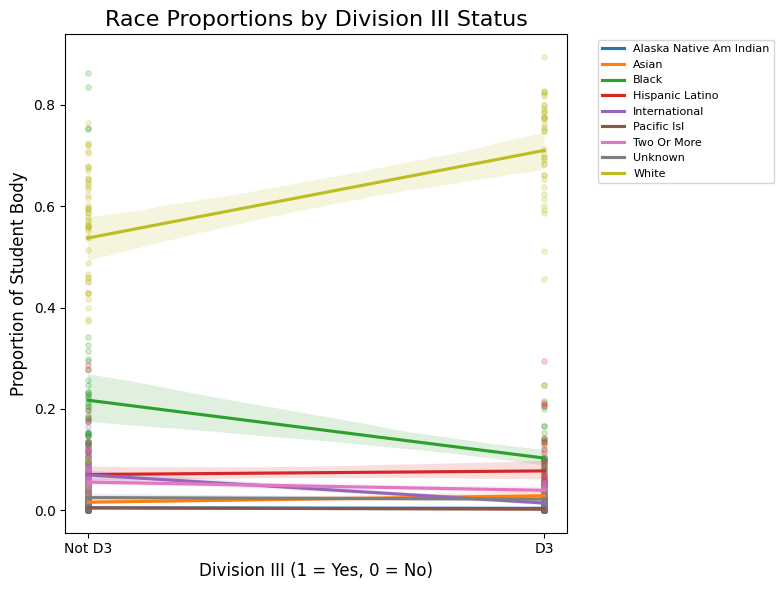


=== OLS Regression Summaries (race proportion ~ division dummies) ===



NameError: name 'LinearRegression' is not defined

In [31]:
diversity_df.columns = diversity_df.columns.str.strip()

# Convert raw counts to proportions of total student body
race_cols_raw = ['alaska_native_am_indian', 'asian', 'black', 'hispanic_latino',
                 'international', 'pacific_isl', 'two_or_more', 'unknown', 'white']

for col in race_cols_raw:
    diversity_df[col] = pd.to_numeric(diversity_df[col], errors='coerce')

diversity_df['total'] = pd.to_numeric(diversity_df['total'], errors='coerce')

race_cols = []
for col in race_cols_raw:
    prop_col = col + '_prop'
    diversity_df[prop_col] = diversity_df[col] / diversity_df['total']
    race_cols.append(prop_col)

# Drop rows with missing values
division_cols = ['division_1', 'division_2', 'division_3']
diversity_df = diversity_df.dropna(subset=race_cols + division_cols)

# ── Plot 1: Race proportions vs Division I ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for col in race_cols:
    sns.regplot(data=diversity_df, x='division_1', y=col,
                scatter_kws={'alpha': 0.2, 's': 15},
                line_kws={'label': col.replace('_prop', '').replace('_', ' ').title()},
                ax=ax)
ax.set_title("Race Proportions by Division I Status", fontsize=16)
ax.set_xlabel('Division I (1 = Yes, 0 = No)', fontsize=12)
ax.set_ylabel('Proportion of Student Body', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not D1', 'D1'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 2: Race proportions vs Division II ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for col in race_cols:
    sns.regplot(data=diversity_df, x='division_2', y=col,
                scatter_kws={'alpha': 0.2, 's': 15},
                line_kws={'label': col.replace('_prop', '').replace('_', ' ').title()},
                ax=ax)
ax.set_title("Race Proportions by Division II Status", fontsize=16)
ax.set_xlabel('Division II (1 = Yes, 0 = No)', fontsize=12)
ax.set_ylabel('Proportion of Student Body', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not D2', 'D2'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 3: Race proportions vs Division III ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for col in race_cols:
    sns.regplot(data=diversity_df, x='division_3', y=col,
                scatter_kws={'alpha': 0.2, 's': 15},
                line_kws={'label': col.replace('_prop', '').replace('_', ' ').title()},
                ax=ax)
ax.set_title("Race Proportions by Division III Status", fontsize=16)
ax.set_xlabel('Division III (1 = Yes, 0 = No)', fontsize=12)
ax.set_ylabel('Proportion of Student Body', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not D3', 'D3'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── OLS Summary: each race proportion ~ all division dummies ────────────────
print("\n=== OLS Regression Summaries (race proportion ~ division dummies) ===\n")

X = diversity_df[division_cols].values

for col in race_cols:
    y = diversity_df[col].values
    mask = ~np.isnan(y)
    model = LinearRegression().fit(X[mask], y[mask])
    r2 = r2_score(y[mask], model.predict(X[mask]))
    label = col.replace('_prop', '').replace('_', ' ').title()
    coefs = dict(zip(division_cols, model.coef_))
    print(f"{label}")
    print(f"  Intercept: {model.intercept_:.4f}  |  R²: {r2:.4f}")
    for div, coef in coefs.items():
        print(f"  {div}: {coef:+.4f}")
    print()

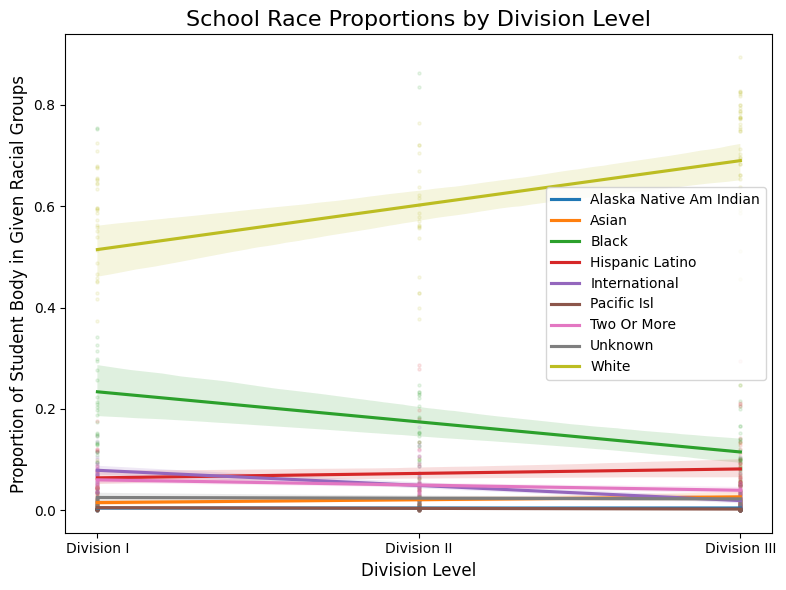

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Load data and strip whitespace from column names
diversity_df = pd.read_excel('../data/division.I.II.III.diversity.xlsx')
diversity_df.columns = diversity_df.columns.str.strip()

# Convert raw counts to proportions of total student body
race_cols_raw = ['alaska_native_am_indian', 'asian', 'black', 'hispanic_latino',
                 'international', 'pacific_isl', 'two_or_more', 'unknown', 'white']

for col in race_cols_raw:
    diversity_df[col] = pd.to_numeric(diversity_df[col], errors='coerce')

diversity_df['total'] = pd.to_numeric(diversity_df['total'], errors='coerce')

race_cols = []
for col in race_cols_raw:
    prop_col = col + '_prop'
    diversity_df[prop_col] = diversity_df[col] / diversity_df['total']
    race_cols.append(prop_col)

# Create a single numeric division variable: 1 = DI, 2 = DII, 3 = DIII
diversity_df['division_num'] = (
    diversity_df['division_1'] * 1 +
    diversity_df['division_2'] * 2 +
    diversity_df['division_3'] * 3
)

# Drop rows with missing values
diversity_df = diversity_df.dropna(subset=race_cols + ['division_num'])

# ── Regression plot: race proportions vs division level ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for col in race_cols:
    sns.regplot(data=diversity_df, x='division_num', y=col,
                scatter_kws={'alpha': 0.1, 's': 5},
                line_kws={'label': col.replace('_prop', '').replace('_', ' ').title()},
                ax=ax)

ax.set_title("School Race Proportions by Division Level", fontsize=16)
ax.set_xlabel('Division Level', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Division I', 'Division II', 'Division III'])
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Part IV

#### The biggest takeaway from this graph is the inverse relationship between Black and white student proportions across division levels. Division I schools have the highest share of Black students at around 23%. This steadily declines toward Division III. White student representation does the opposite, growing larger as division level decreases. 

#### This pattern could likely reflect that high-profile athletic recruitment in Division I draws more Black student athletes, while Division III schools, which offer no athletic scholarships, tend to enroll a much whiter student body.


#### This shows that when it comes to racial diversity and division status, there is a prominent story between the Black-white dynamic. Athletic structure and scholarship access may play a bigger role in shaping campus demographics than we might assume.


#### For every other racial group (Hispanic/Latino, Asian, International, etc.) division level doesn't seem to matter much. Their proportions stay low and relatively flat across all three divisions, clustering near or below 10%. 
